# Map Tearing Diagnostics on MNIST: t-SNE, UMAP, and DimBridge Validation

This notebook investigates where 2D embeddings create **map tears**: cases where points that are neighbors in the high-dimensional MNIST representation become separated in the 2D projection.

The workflow is:

1. Load MNIST and build a PCA-50 high-dimensional representation.
2. Build mutual-kNN pairs in the high-dimensional space.
3. Compute 2D t-SNE and UMAP embeddings.
4. Score and visualize potential map tears.
5. Build a tear-focused DimBridge subset.
6. Validate the tear-aware DimBridge brushing prototype.

**Status:** research prototype, still in progress.


## 0. Imports and environment check

This notebook assumes the project environment has already been installed from the repository README. Avoid installing packages inside the notebook during review unless the environment is missing dependencies.


### Environment verification

Run this cell to confirm that the notebook uses the editable DimBridge fork, not a separately installed package.


In [2]:
import sys
import dimbridge

print(sys.executable)
print(dimbridge.__file__)

/Users/nawaf/Desktop/research/Dimbridge/.venv/bin/python
/Users/nawaf/Desktop/research/Dimbridge/dimbridge-jupyter-fork/src/dimbridge/__init__.py


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

# UMAP (install if needed)
import umap.umap_ as umap

## 1. Load MNIST and build high-D representation (PCA-50)

In [4]:
# Load MNIST (70k x 784)
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

# Scale pixels to [0, 1]
X = MinMaxScaler().fit_transform(X)

# High-D neighbor space (PCA-50) for speed/denoising
pca = PCA(n_components=50, random_state=42)
X_hd = pca.fit_transform(X)

print("X:", X.shape, "X_hd:", X_hd.shape, "y:", y.shape)


X: (70000, 784) X_hd: (70000, 50) y: (70000,)


## 2. Mutual-kNN pairs in high-D (k=15)

In [5]:
k = 15
nn = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
nn.fit(X_hd)

distances, indices = nn.kneighbors(X_hd)

# Remove self neighbor
nbrs = indices[:, 1:]
dists = distances[:, 1:]

# Mutual-kNN (reduces one-sided neighbor noise)
nbr_set = [set(row) for row in nbrs]

mutual_knn_pairs = []
mutual_knn_hd_dist = []

for i in range(len(X_hd)):
    for t, j in enumerate(nbrs[i]):
        if i in nbr_set[j]:          # mutual
            if i < j:                # keep unique undirected pair
                mutual_knn_pairs.append((i, j))
                mutual_knn_hd_dist.append(dists[i, t])

mutual_knn_hd_dist = np.array(mutual_knn_hd_dist)
print("Num mutual-kNN pairs:", len(mutual_knn_pairs))


Num mutual-kNN pairs: 300203


## 3. 2D embeddings (t-SNE and UMAP)

In [6]:
# t-SNE (perplexity chosen to match k=15)
tsne = TSNE(
    n_components=2,
    perplexity=15,
    init="random",
    random_state=42
)
Y_tsne = tsne.fit_transform(X_hd)
print("Y_tsne:", Y_tsne.shape)

# UMAP (n_neighbors chosen to match k=15)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
Y_umap = reducer.fit_transform(X_hd)
print("Y_umap:", Y_umap.shape)


Y_tsne: (70000, 2)


/Users/nawaf/Desktop/research/Dimbridge/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Y_umap: (70000, 2)


## 4. Helpers: normalize embedding scale + compute distortion ratios

In [7]:
def normalize_by_median_knn_distance(Z, k=15):
    """Center Z and scale so median distance to the k-th neighbor is 1."""
    Z = Z - Z.mean(axis=0, keepdims=True)
    nn = NearestNeighbors(n_neighbors=k+1).fit(Z)
    d, _ = nn.kneighbors(Z)
    scale = np.median(d[:, -1])  # distance to k-th neighbor
    return Z / (scale + 1e-12), scale

def compute_pair_distortion(Y_embed, pairs, hd_dists, k=15, eps=1e-8):
    """Returns normalized embedding, scale factor, and per-pair distortion ratios."""
    Y_norm, scale = normalize_by_median_knn_distance(Y_embed, k=k)
    ratios = np.array([
        np.linalg.norm(Y_norm[i] - Y_norm[j]) / (d_hd + eps)
        for (i, j), d_hd in zip(pairs, hd_dists)
    ])
    return Y_norm, scale, ratios

def compute_hotspots(pairs, ratios, top_m=300, n_points=None):
    """Count how often each point participates in the top_m most distorted pairs."""
    if n_points is None:
        n_points = max(max(i, j) for (i, j) in pairs) + 1
    sorted_idx = np.argsort(ratios)[::-1]
    top_idx = sorted_idx[:top_m]
    score = np.zeros(n_points, dtype=float)
    for idx in top_idx:
        i, j = pairs[idx]
        score[i] += 1
        score[j] += 1
    return score, sorted_idx

def plot_edges(Y_norm, pairs, title, n_edges=50):
    plt.figure(figsize=(8, 8))
    plt.scatter(Y_norm[:, 0], Y_norm[:, 1], s=5, alpha=0.5, color="black")
    for (i, j) in pairs[:n_edges]:
        plt.plot([Y_norm[i, 0], Y_norm[j, 0]],
                 [Y_norm[i, 1], Y_norm[j, 1]],
                 color="red", alpha=0.35, linewidth=1.2)
    plt.title(title)
    plt.show()

def plot_hotspots(Y_norm, tear_score, title):
    plt.figure(figsize=(8, 8))
    plt.scatter(Y_norm[:, 0], Y_norm[:, 1], c=tear_score, s=5)
    plt.colorbar(label="hotspot score (top 300 pairs)")
    plt.title(title)
    plt.show()

def show_mnist_pairs(pairs, X784, y_labels, scores=None, n_show=12):
    n_show = min(n_show, len(pairs))
    fig, axes = plt.subplots(n_show, 2, figsize=(5, 2.2 * n_show))
    if n_show == 1:
        axes = np.array([axes])

    for r, (i, j) in enumerate(pairs[:n_show]):
        axes[r, 0].imshow(X784[i].reshape(28, 28), cmap="gray")
        axes[r, 0].axis("off")
        axes[r, 0].set_title(f"Pair {r+1}: i={i}, y={int(y_labels[i])}", fontsize=9)

        axes[r, 1].imshow(X784[j].reshape(28, 28), cmap="gray")
        axes[r, 1].axis("off")
        t = f"j={j}, y={int(y_labels[j])}"
        if scores is not None:
            t += f"\nratio={float(scores[r]):.2f}"
        axes[r, 1].set_title(t, fontsize=9)

    plt.tight_layout()
    plt.show()


## 5. Tear diagnostics: t-SNE

t-SNE scale factor: 1.3181511006810496
t-SNE hotspot fraction (score>0): 0.0054571428571428575


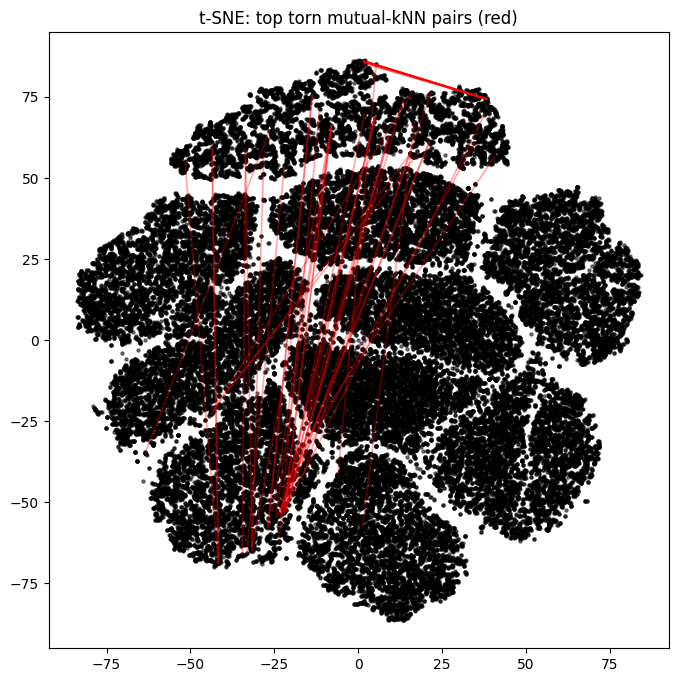

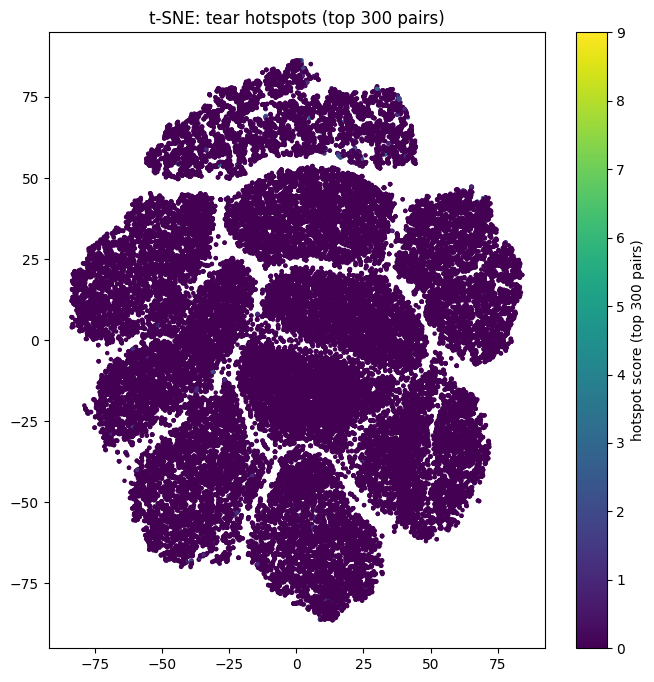

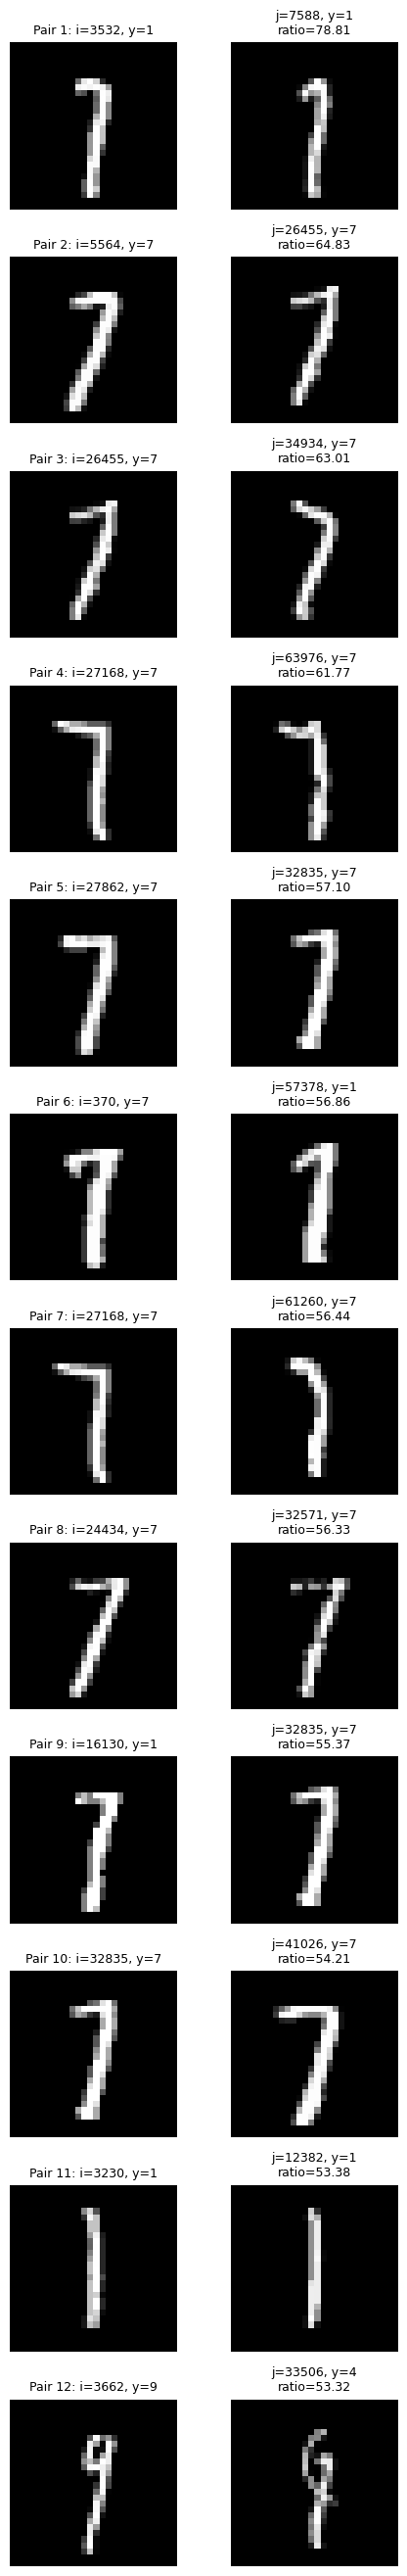

In [8]:
Y_tsne_norm, tsne_scale, ratios_tsne = compute_pair_distortion(
    Y_tsne, mutual_knn_pairs, mutual_knn_hd_dist, k=15
)
tear_score_tsne, sorted_idx_tsne = compute_hotspots(
    mutual_knn_pairs, ratios_tsne, top_m=300, n_points=len(Y_tsne_norm)
)

# Top edges (ranked by ratio) for visualization
top_pairs_tsne = [mutual_knn_pairs[idx] for idx in sorted_idx_tsne]

print("t-SNE scale factor:", tsne_scale)
print("t-SNE hotspot fraction (score>0):", np.mean(tear_score_tsne > 0))

plot_edges(Y_tsne_norm, top_pairs_tsne, "t-SNE: top torn mutual-kNN pairs (red)", n_edges=50)
plot_hotspots(Y_tsne_norm, tear_score_tsne, "t-SNE: tear hotspots (top 300 pairs)")

# Inspect image pairs for the worst torn edges
top_scores_tsne = ratios_tsne[sorted_idx_tsne][:12]
top_pairs_list_tsne = [mutual_knn_pairs[idx] for idx in sorted_idx_tsne[:12]]
show_mnist_pairs(top_pairs_list_tsne, X, y, scores=top_scores_tsne, n_show=12)


## 6. Tear diagnostics: UMAP

UMAP scale factor: 0.06833828455535318
UMAP hotspot fraction (score>0): 0.005857142857142857


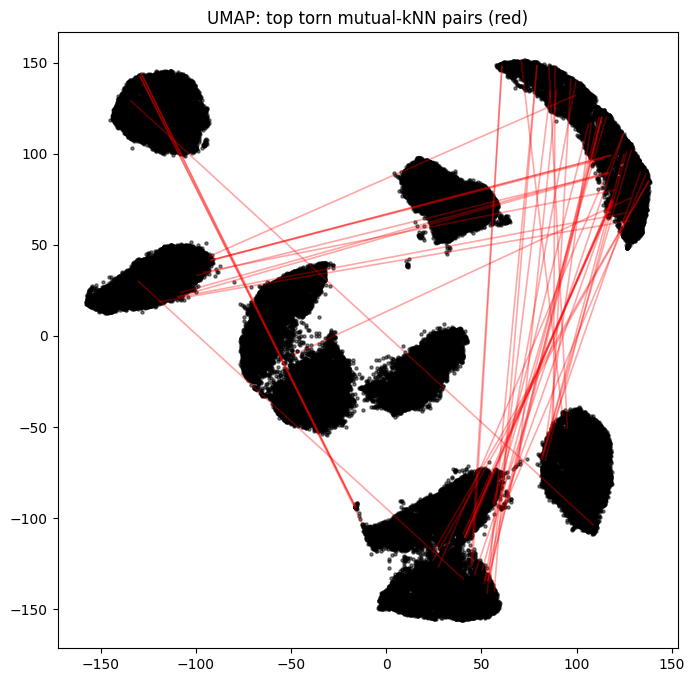

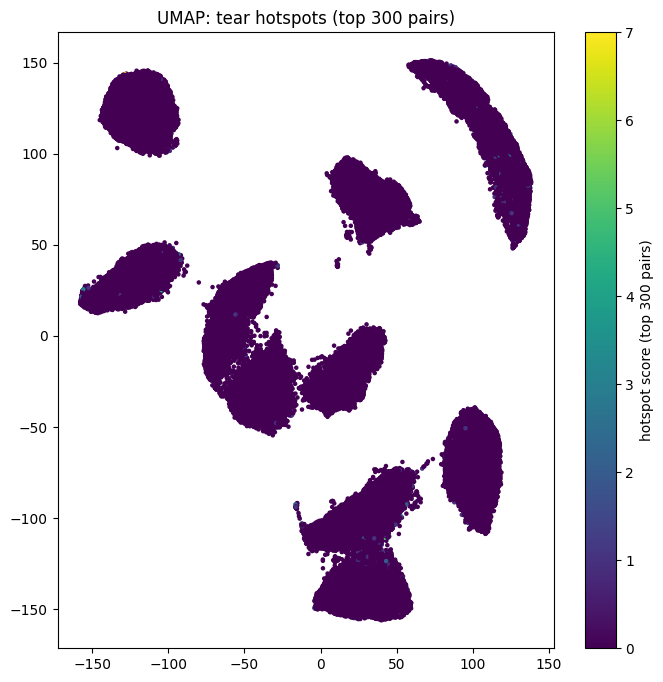

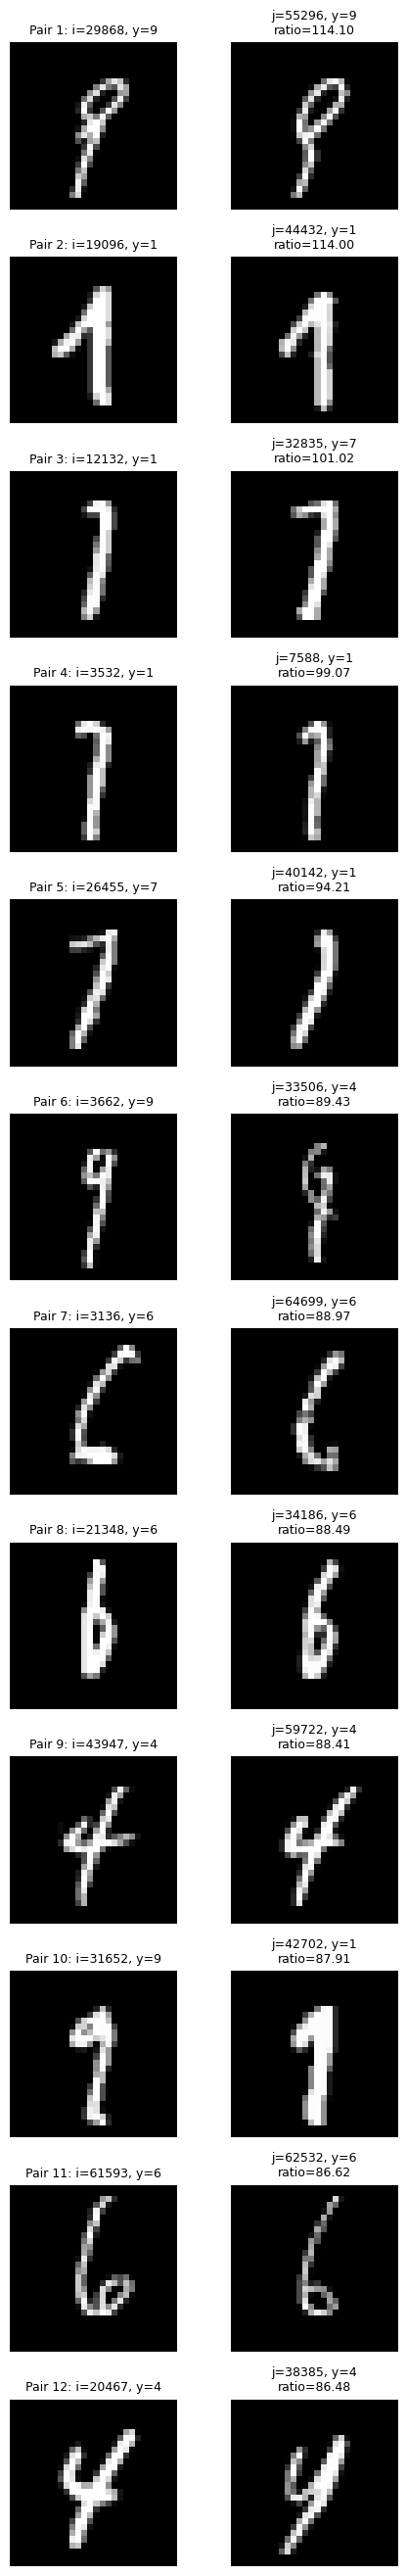

In [9]:
Y_umap_norm, umap_scale, ratios_umap = compute_pair_distortion(
    Y_umap, mutual_knn_pairs, mutual_knn_hd_dist, k=15
)
tear_score_umap, sorted_idx_umap = compute_hotspots(
    mutual_knn_pairs, ratios_umap, top_m=300, n_points=len(Y_umap_norm)
)

top_pairs_umap = [mutual_knn_pairs[idx] for idx in sorted_idx_umap]

print("UMAP scale factor:", umap_scale)
print("UMAP hotspot fraction (score>0):", np.mean(tear_score_umap > 0))

plot_edges(Y_umap_norm, top_pairs_umap, "UMAP: top torn mutual-kNN pairs (red)", n_edges=50)
plot_hotspots(Y_umap_norm, tear_score_umap, "UMAP: tear hotspots (top 300 pairs)")

# Inspect image pairs for the worst torn edges
top_scores_umap = ratios_umap[sorted_idx_umap][:12]
top_pairs_list_umap = [mutual_knn_pairs[idx] for idx in sorted_idx_umap[:12]]
show_mnist_pairs(top_pairs_list_umap, X, y, scores=top_scores_umap, n_show=12)


## 7A. Additional metrics: neighborhood-overlap tear score and low-D outlier score

This section computes two supporting diagnostics:

- `T(i)`: neighborhood-overlap tear score, measuring how much each point's neighborhood changes from high-D to low-D.
- `R_low(i)`: low-dimensional kNN radius, used as a projection outlier score.


In [10]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Reuse high-D neighbors already computed in Section 2:
# nbrs: shape (n, k) from PCA-50 space
# mutual_knn_pairs: list of (i,j) mutual-kNN edges in high-D

def lowD_neighbors_and_scores(Y_norm, nbrs_high, k=15):
    """
    Returns:
      N_low: (n, k) low-D neighbor indices
      R_low: (n,) low-D kNN radius (distance to k-th neighbor)
      T:     (n,) neighborhood-overlap tear score: 1 - |N_high ∩ N_low|/k
    """
    nn_low = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
    nn_low.fit(Y_norm)
    dist_low, ind_low = nn_low.kneighbors(Y_norm)

    # drop self
    N_low = ind_low[:, 1:]
    D_low = dist_low[:, 1:]

    # outlier score: distance to k-th neighbor in low-D
    R_low = D_low[:, -1]

    # compute overlap size between N_high and N_low
    N_low_sets = [set(row) for row in N_low]
    overlap = np.zeros(len(N_low), dtype=np.int32)
    for i in range(len(N_low)):
        overlap[i] = sum((j in N_low_sets[i]) for j in nbrs_high[i])

    T = 1.0 - overlap / float(k)
    return N_low, R_low, T

# Compute for t-SNE and UMAP
N_low_tsne, R_low_tsne, T_tsne = lowD_neighbors_and_scores(Y_tsne_norm, nbrs, k=k)
N_low_umap, R_low_umap, T_umap = lowD_neighbors_and_scores(Y_umap_norm, nbrs, k=k)

print("T(i) summary:")
print("  t-SNE  min/mean/max:", T_tsne.min(), T_tsne.mean(), T_tsne.max())
print("  UMAP   min/mean/max:", T_umap.min(), T_umap.mean(), T_umap.max())

print("\nR_low(i) summary (low-D outlier radius):")
print("  t-SNE  min/mean/max:", R_low_tsne.min(), R_low_tsne.mean(), R_low_tsne.max())
print("  UMAP   min/mean/max:", R_low_umap.min(), R_low_umap.mean(), R_low_umap.max())

T(i) summary:
  t-SNE  min/mean/max: 0.06666666666666665 0.6252590476190476 1.0
  UMAP   min/mean/max: 0.06666666666666665 0.8727590476190477 1.0

R_low(i) summary (low-D outlier radius):
  t-SNE  min/mean/max: 0.3527033201991289 1.0390168747318036 4.6464097875150765
  UMAP   min/mean/max: 0.24574691453184452 1.0685563083602625 17.732218202260817


## 7B. Pair-level metric: torn mutual-kNN pairs

A high-dimensional mutual-kNN pair is treated as torn if the pair is not preserved in the low-dimensional top-k neighborhoods.


In [11]:
import numpy as np

def torn_pairs_from_lowD(mutual_pairs, N_low, k=15):
    """
    A mutual-kNN pair (i,j) is 'torn' if j not in i's low-D top-k OR i not in j's low-D top-k.
    Returns a boolean mask and a simple severity score based on low-D distance rank proxy:
      severity = 1 if neither contains the other, 0.5 if only one-sided preserved.
    """
    N_low_sets = [set(row) for row in N_low]

    torn = []
    severity = []
    for (i, j) in mutual_pairs:
        in_i = (j in N_low_sets[i])
        in_j = (i in N_low_sets[j])
        is_torn = (not in_i) or (not in_j)
        torn.append(is_torn)

        # severity: 1.0 if both missing, 0.5 if one-sided missing, 0 if preserved
        if (not in_i) and (not in_j):
            severity.append(1.0)
        elif (not in_i) or (not in_j):
            severity.append(0.5)
        else:
            severity.append(0.0)

    return np.array(torn, dtype=bool), np.array(severity, dtype=float)

torn_mask_tsne, torn_sev_tsne = torn_pairs_from_lowD(mutual_knn_pairs, N_low_tsne, k=k)
torn_mask_umap, torn_sev_umap = torn_pairs_from_lowD(mutual_knn_pairs, N_low_umap, k=k)

print("Torn mutual-kNN pairs (pair-level):")
print("  t-SNE:", torn_mask_tsne.mean(), "fraction torn")
print("  UMAP :", torn_mask_umap.mean(), "fraction torn")


Torn mutual-kNN pairs (pair-level):
  t-SNE: 0.5249514495191587 fraction torn
  UMAP : 0.8542552872556237 fraction torn


## 7C. Plots for additional tear metrics

These plots help compare where t-SNE and UMAP create local neighborhood distortions.


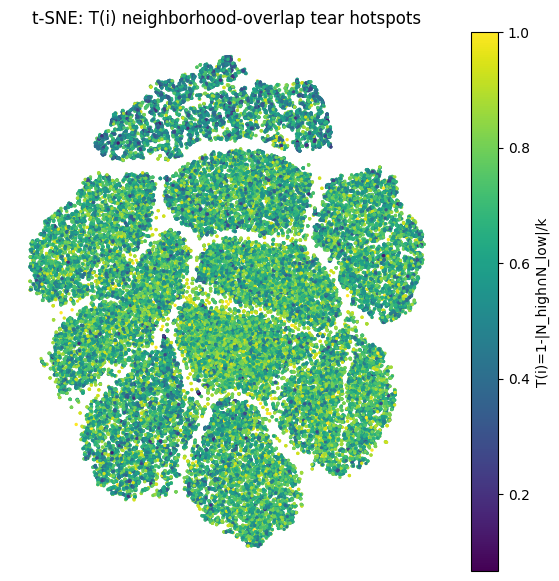

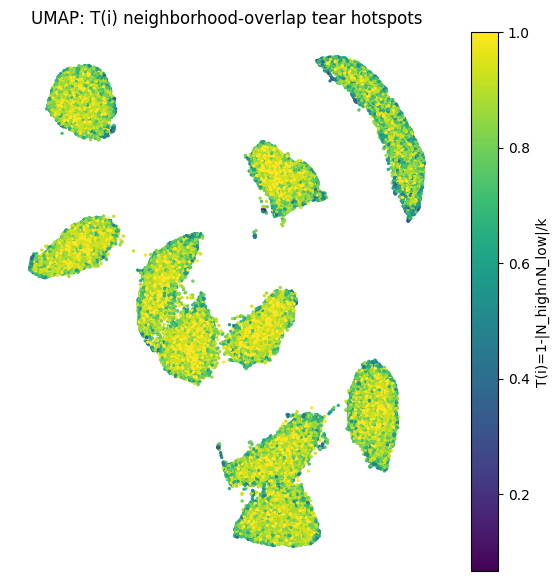

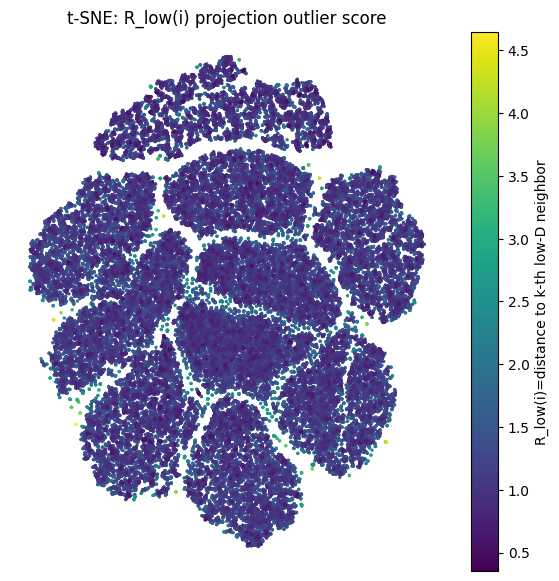

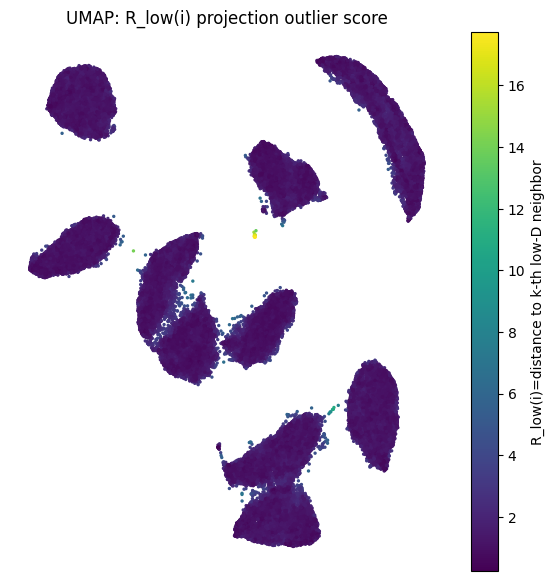

In [12]:
import matplotlib.pyplot as plt

def plot_metric(Y_norm, metric, title, cbar_label):
    plt.figure(figsize=(7,7))
    plt.scatter(Y_norm[:,0], Y_norm[:,1], c=metric, s=2)
    plt.colorbar(label=cbar_label)
    plt.title(title)
    plt.axis("off")
    plt.show()

# T(i): neighborhood-overlap tear hotspots
plot_metric(Y_tsne_norm, T_tsne, "t-SNE: T(i) neighborhood-overlap tear hotspots", "T(i)=1-|N_high∩N_low|/k")
plot_metric(Y_umap_norm, T_umap, "UMAP: T(i) neighborhood-overlap tear hotspots", "T(i)=1-|N_high∩N_low|/k")

# R_low: low-D outlier radius
plot_metric(Y_tsne_norm, R_low_tsne, "t-SNE: R_low(i) projection outlier score", "R_low(i)=distance to k-th low-D neighbor")
plot_metric(Y_umap_norm, R_low_umap, "UMAP: R_low(i) projection outlier score", "R_low(i)=distance to k-th low-D neighbor")

## 8. Quick comparison summary

Absolute distortion values are scale-sensitive, so this notebook reports mostly rank-based or percentile-based comparisons.


In [13]:
def tail_mean(ratios, q=99):
    tau = np.percentile(ratios, q)
    return ratios[ratios >= tau].mean()

print("Tail mean (top 1%) — within-run only (scale ambiguous):")
print("  t-SNE:", tail_mean(ratios_tsne, 99))
print("  UMAP :", tail_mean(ratios_umap, 99))

print("\nStable reporting recommendation:")
print("  Compare embeddings by where hotspots appear and which pairs fall in top-N (rank-based),")
print("  rather than using the absolute ratio value across different runs/algorithms.")


Tail mean (top 1%) — within-run only (scale ambiguous):
  t-SNE: 16.847850758370715
  UMAP : 29.473450446170677

Stable reporting recommendation:
  Compare embeddings by where hotspots appear and which pairs fall in top-N (rank-based),
  rather than using the absolute ratio value across different runs/algorithms.


## 9. Exploratory clustering analysis

This section is exploratory. It checks how low-dimensional clustering relates to the embedding structure and potential tear regions.


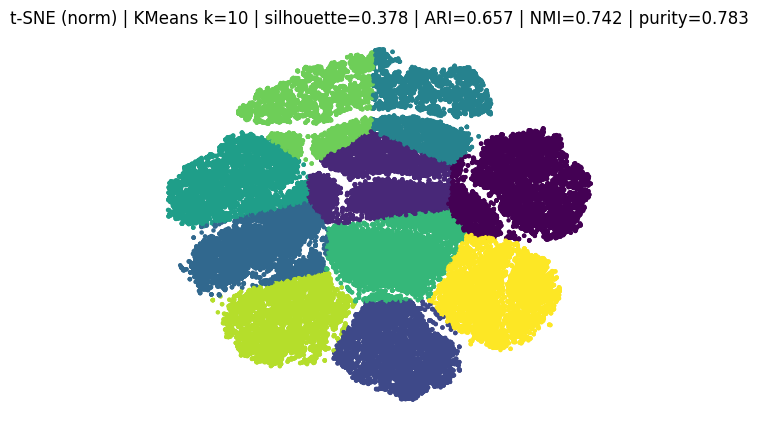

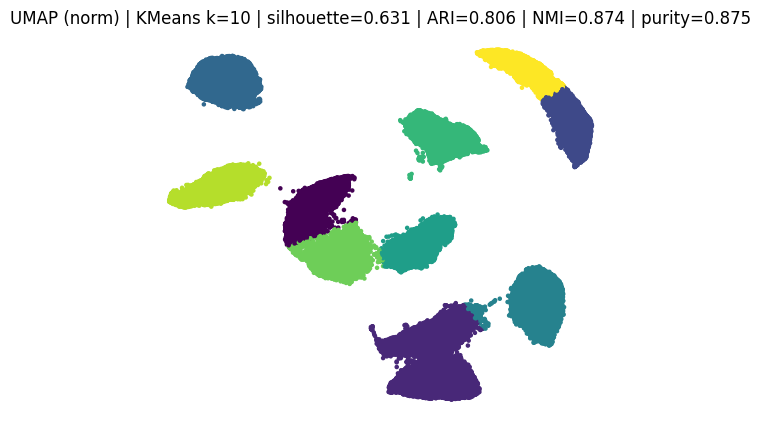

t-SNE cluster sizes: [8821 7424 6699 6489 6277 6640 7841 5828 6449 7532]
UMAP cluster sizes: [ 6021 13465  4258  6932  7620  6603  6997  7487  6978  3639]


In [14]:
# --- KMeans on lowD (normalized) embeddings: t-SNE vs UMAP ---
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

def kmeans_lowd(Z, name, y_true=None, k=10, seed=42):
    """
    Z: (n,2) lowD embedding (use *norm vars*)
    y_true: optional ground-truth labels (e.g., MNIST digits) for ARI/NMI
    """
    km = KMeans(n_clusters=k, n_init=20, random_state=seed)
    c = km.fit_predict(Z)

    # intrinsic clusterability in this 2D space
    sil = silhouette_score(Z, c)

    ari = nmi = None
    if y_true is not None:
        ari = adjusted_rand_score(y_true, c)
        nmi = normalized_mutual_info_score(y_true, c)

    # simple "purity" (best label per cluster)
    purity = None
    if y_true is not None:
        purity_sum = 0
        for j in range(k):
            idx = (c == j)
            if idx.sum() == 0:
                continue
            labels, counts = np.unique(np.asarray(y_true)[idx], return_counts=True)
            purity_sum += counts.max()
        purity = purity_sum / len(y_true)

    # plot
    plt.figure(figsize=(6, 5))
    plt.scatter(Z[:, 0], Z[:, 1], s=5, c=c)
    title = f"{name} | KMeans k={k} | silhouette={sil:.3f}"
    if y_true is not None:
        title += f" | ARI={ari:.3f} | NMI={nmi:.3f}"
        if purity is not None:
            title += f" | purity={purity:.3f}"
    plt.title(title)
    plt.axis("off")
    plt.show()

    return {
        "labels": c,
        "centers": km.cluster_centers_,
        "silhouette": sil,
        "ARI": ari,
        "NMI": nmi,
        "purity": purity
    }

# Use the normalized lowD vars (
res_tsne = kmeans_lowd(Y_tsne_norm, "t-SNE (norm)", y_true=y, k=10, seed=42)
res_umap = kmeans_lowd(Y_umap_norm, "UMAP (norm)", y_true=y, k=10, seed=42)

print("t-SNE cluster sizes:", np.bincount(res_tsne["labels"]))
print("UMAP cluster sizes:", np.bincount(res_umap["labels"]))

## 10. Top tear examples and extrapolation analysis

This section highlights the top tear candidates and explores how they relate to low-dimensional clusters and high-dimensional structure.



t-SNE — Top 10 by tear_score (hotspot count):


,rank,idx,digit,kmeans,tear_score(i),T(i),R_low(i)
0,1,34486,0,0,9.0,0.600000,0.758742
1,2,3230,1,4,7.0,0.466667,0.916177
2,3,14440,4,3,7.0,0.666667,1.604690
3,4,12382,1,4,6.0,0.466667,0.935573
4,5,44432,1,4,6.0,0.666667,0.875322
5,6,32886,1,4,5.0,0.600000,1.038364
6,7,18442,1,4,5.0,0.466667,0.965325
7,8,11326,1,4,5.0,0.400000,0.958061
8,9,6708,0,0,5.0,0.533333,0.936952
9,10,19494,9,3,5.0,0.466667,1.598719



t-SNE — Top 10 by T(i) (neighbor-overlap tear):


,rank,idx,digit,kmeans,T(i),tear_score(i),R_low(i)
0,1,38389,7,8,1.0,0.0,4.646410
1,2,57084,8,6,1.0,0.0,1.025144
2,3,30473,0,0,1.0,0.0,1.465057
3,4,63662,8,6,1.0,0.0,1.845726
4,5,57532,8,6,1.0,0.0,1.552678
5,6,69850,0,0,1.0,0.0,1.468508
6,7,11572,5,0,1.0,0.0,2.678643
7,8,30369,2,2,1.0,0.0,1.251302
8,9,50829,1,4,1.0,0.0,1.320020
9,10,65804,3,9,1.0,0.0,1.167925



UMAP — Top 10 by tear_score (hotspot count):


,rank,idx,digit,kmeans,tear_score(i),T(i),R_low(i)
0,1,35632,0,3,7.0,0.933333,1.760673
1,2,14440,4,1,6.0,0.533333,1.544941
2,3,53168,1,2,6.0,0.733333,0.916097
3,4,8704,1,2,5.0,0.933333,1.809535
4,5,37060,9,2,5.0,0.666667,0.766317
5,6,24084,4,1,5.0,0.866667,1.248750
6,7,44432,1,1,5.0,0.666667,1.569615
7,8,13376,3,2,5.0,0.733333,1.529028
8,9,54778,4,8,4.0,0.800000,1.664156
9,10,19494,9,1,4.0,0.733333,1.300099



UMAP — Top 10 by T(i) (neighbor-overlap tear):


,rank,idx,digit,kmeans,T(i),tear_score(i),R_low(i)
0,1,0,5,0,1.0,0.0,1.174973
1,2,15254,7,4,1.0,0.0,1.413849
2,3,48339,8,5,1.0,0.0,0.982315
3,4,48341,7,4,1.0,0.0,1.095751
4,5,48342,4,1,1.0,0.0,1.224020
5,6,15267,8,5,1.0,0.0,0.915632
6,7,48347,9,1,1.0,0.0,1.046442
7,8,48348,5,0,1.0,0.0,0.711961
8,9,48351,8,5,1.0,0.0,0.806940
9,10,15257,6,8,1.0,0.0,0.602031


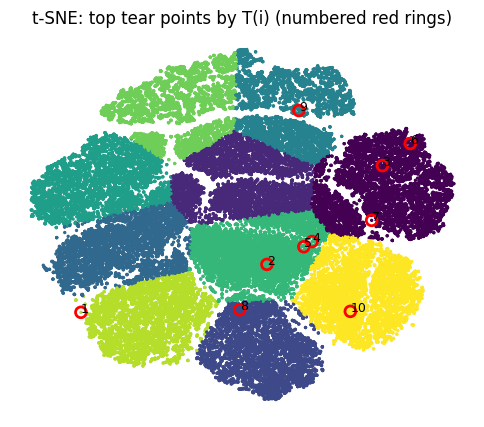

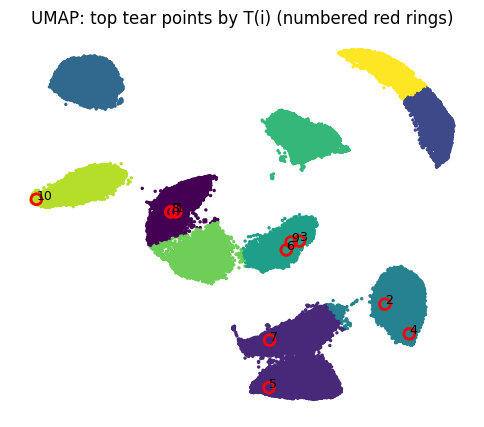

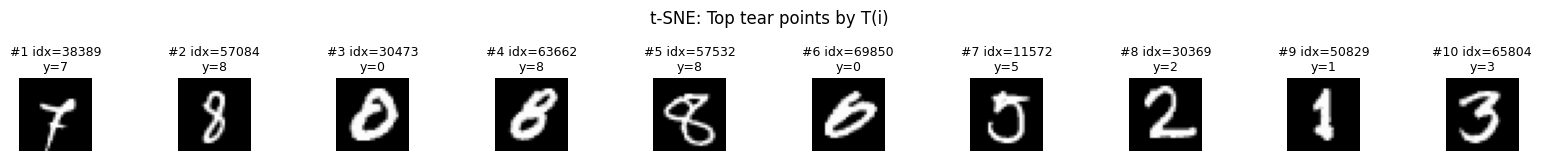

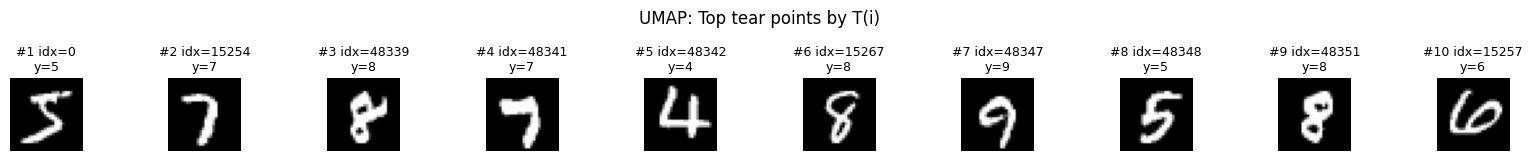

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 10

# Helper: robustly cast labels from OpenML (often strings) to ints for readability
y_int = np.array(y, dtype=int) if y.dtype.kind in "OUS" else np.array(y)

def topk_indices(metric, k=10):
    metric = np.asarray(metric)
    return np.argsort(metric)[::-1][:k]

def highlight_on_embedding(Y_norm, base_c=None, top_idx=None, title=""):
    plt.figure(figsize=(6,5))
    if base_c is None:
        plt.scatter(Y_norm[:,0], Y_norm[:,1], s=2)
    else:
        plt.scatter(Y_norm[:,0], Y_norm[:,1], s=2, c=base_c)
    if top_idx is not None and len(top_idx) > 0:
        plt.scatter(Y_norm[top_idx,0], Y_norm[top_idx,1], s=60, facecolors="none", edgecolors="red", linewidths=2)
        for rank, i in enumerate(top_idx):
            plt.text(Y_norm[i,0], Y_norm[i,1], str(rank+1), fontsize=9)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_mnist(indices, X, y, n_cols=10, title=""):
    n = len(indices)
    n_rows = int(np.ceil(n / n_cols))
    plt.figure(figsize=(1.6*n_cols, 1.6*n_rows))
    for j, idx in enumerate(indices):
        plt.subplot(n_rows, n_cols, j+1)
        plt.imshow(X[idx].reshape(28,28), cmap="gray")
        plt.title(f"#{j+1} idx={idx}\ny={int(y_int[idx])}", fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# If you have kmeans results stored as res_tsne/res_umap from earlier:
k_tsne = res_tsne["labels"] if "res_tsne" in globals() else None
k_umap = res_umap["labels"] if "res_umap" in globals() else None

# ---- Top-10 tear points by two metrics ----
top_tsne_hot = topk_indices(tear_score_tsne, TOP_N)  # "edge-distortion hotspot" count
top_umap_hot = topk_indices(tear_score_umap, TOP_N)

top_tsne_T = topk_indices(T_tsne, TOP_N)             # neighborhood-overlap tear score
top_umap_T = topk_indices(T_umap, TOP_N)

# ---- Summaries (table) ----
def make_table(name, idxs_hot, idxs_T, tear_score, T, R_low, kmeans_labels=None):
    def rows(idxs, metric_name):
        out = []
        for r, i in enumerate(idxs, start=1):
            out.append({
                "rank": r,
                "idx": int(i),
                "digit": int(y_int[i]),
                "kmeans": (int(kmeans_labels[i]) if kmeans_labels is not None else None),
                metric_name: float((tear_score[i] if metric_name=="tear_score" else T[i])),
                "T(i)": float(T[i]),
                "R_low(i)": float(R_low[i]),
                "tear_score(i)": float(tear_score[i]),
            })
        return out

    df = pd.DataFrame(rows(idxs_hot, "tear_score"))
    df2 = pd.DataFrame(rows(idxs_T, "T(i)"))
    print(f"\n{name} — Top {TOP_N} by tear_score (hotspot count):")
    display(df[["rank","idx","digit","kmeans","tear_score(i)","T(i)","R_low(i)"]])
    print(f"\n{name} — Top {TOP_N} by T(i) (neighbor-overlap tear):")
    display(df2[["rank","idx","digit","kmeans","T(i)","tear_score(i)","R_low(i)"]])

make_table("t-SNE", top_tsne_hot, top_tsne_T, tear_score_tsne, T_tsne, R_low_tsne, k_tsne)
make_table("UMAP", top_umap_hot, top_umap_T, tear_score_umap, T_umap, R_low_umap, k_umap)

# ---- Visualize where they sit on the embeddings ----
highlight_on_embedding(Y_tsne_norm, base_c=k_tsne, top_idx=top_tsne_T,
                       title="t-SNE: top tear points by T(i) (numbered red rings)")
highlight_on_embedding(Y_umap_norm, base_c=k_umap, top_idx=top_umap_T,
                       title="UMAP: top tear points by T(i) (numbered red rings)")

# ---- Inspect the actual MNIST images for the worst tear points ----
show_mnist(top_tsne_T, X, y, n_cols=10, title="t-SNE: Top tear points by T(i)")
show_mnist(top_umap_T, X, y, n_cols=10, title="UMAP: Top tear points by T(i)")

In [16]:
# --- Extrapolate tears to lowD k-means clusters + highD centroid similarity ---
import numpy as np

def cluster_centroid(X_hd, c, cluster_id):
    idx = np.where(c == cluster_id)[0]
    return X_hd[idx].mean(axis=0), idx.size

def cosine_sim(a, b, eps=1e-12):
    return float(a @ b / ((np.linalg.norm(a) * np.linalg.norm(b)) + eps))

def find_largest_cross_cluster_tear(mutual_pairs, ratios, torn_mask, torn_sev, c_lowd):
    """
    mutual_pairs: list[(i,j)] mutual-kNN edges in highD
    ratios: per-pair distortion ratio in lowD (already computed in your notebook)
    torn_mask: bool per pair (True if torn)
    torn_sev: per pair severity (0.5 or 1.0)
    c_lowd: kmeans labels for each point in lowD
    """
    P = np.asarray(mutual_pairs, dtype=int)          # (m,2)
    i_idx, j_idx = P[:, 0], P[:, 1]

    cross = (c_lowd[i_idx] != c_lowd[j_idx])
    valid = torn_mask & cross

    if not np.any(valid):
        return None

    # Tear "magnitude": distortion ratio, optionally weighted by severity
    score = ratios * torn_sev
    best = np.argmax(np.where(valid, score, -np.inf))

    i, j = int(i_idx[best]), int(j_idx[best])
    return {
        "pair_index": int(best),
        "i": i, "j": j,
        "ci": int(c_lowd[i]), "cj": int(c_lowd[j]),
        "ratio": float(ratios[best]),
        "severity": float(torn_sev[best]),
        "score": float(score[best])
    }

def report_for_embedding(name, mutual_pairs, ratios, torn_mask, torn_sev, res_kmeans, X_hd, y):
    c = res_kmeans["labels"]
    best = find_largest_cross_cluster_tear(mutual_pairs, ratios, torn_mask, torn_sev, c)
    if best is None:
        print(f"{name}: no torn pairs crossing different k-means clusters.")
        return

    i, j = best["i"], best["j"]
    ci, cj = best["ci"], best["cj"]

    mu_i, n_i = cluster_centroid(X_hd, c, ci)
    mu_j, n_j = cluster_centroid(X_hd, c, cj)

    euclid = float(np.linalg.norm(mu_i - mu_j))
    cos = cosine_sim(mu_i, mu_j)

    print(f"\n{name} — largest cross-cluster torn pair (by ratio*severity)")
    print(f"  pair: (i={i}, j={j})   digits: (y_i={int(y[i])}, y_j={int(y[j])})")
    print(f"  lowD kmeans clusters: (c_i={ci}, c_j={cj})")
    print(f"  tear: ratio={best['ratio']:.6f}, severity={best['severity']:.1f}, score={best['score']:.6f}")
    print(f"  highD centroid similarity between clusters {ci} vs {cj}:")
    print(f"    sizes: n_i={n_i}, n_j={n_j}")
    print(f"    centroid L2 distance: {euclid:.6f}")
    print(f"    centroid cosine similarity: {cos:.6f}")

# Run for both embeddings:
# mutual_knn_pairs, ratios_tsne, ratios_umap, torn_mask_tsne, torn_sev_tsne, torn_mask_umap, torn_sev_umap,
# res_tsne, res_umap, X_hd, y

report_for_embedding("t-SNE", mutual_knn_pairs, ratios_tsne, torn_mask_tsne, torn_sev_tsne, res_tsne, X_hd, y)
report_for_embedding("UMAP", mutual_knn_pairs, ratios_umap, torn_mask_umap, torn_sev_umap, res_umap, X_hd, y)


t-SNE — largest cross-cluster torn pair (by ratio*severity)
  pair: (i=3532, j=7588)   digits: (y_i=1, y_j=1)
  lowD kmeans clusters: (c_i=8, c_j=4)
  tear: ratio=78.811807, severity=1.0, score=78.811807
  highD centroid similarity between clusters 8 vs 4:
    sizes: n_i=6449, n_j=6277
    centroid L2 distance: 5.111417
    centroid cosine similarity: -0.135041

UMAP — largest cross-cluster torn pair (by ratio*severity)
  pair: (i=29868, j=55296)   digits: (y_i=9, y_j=9)
  lowD kmeans clusters: (c_i=9, c_j=1)
  tear: ratio=114.101150, severity=1.0, score=114.101150
  highD centroid similarity between clusters 9 vs 1:
    sizes: n_i=3639, n_j=13465
    centroid L2 distance: 6.223268
    centroid cosine similarity: -0.265120


# 11. DimBridge validation: tear-aware brushing

This section prepares a smaller tear-focused subset for DimBridge and validates the modified brushing logic.

The key idea is to pass a numeric `tear_flag` into DimBridge:

- `tear_flag = 1.0`: point is one of the selected top-tear endpoints.
- `tear_flag = 0.0`: normal context point.

The modified `ProjectionView.brush_end(event)` then reports how many tear points are inside the brushed region.


In [17]:
import numpy as np
import pandas as pd
from dimbridge import Dimbridge

In [18]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

N_DIMBRIDGE_PCS = 20
PAIR_TOP_N_FOR_CONTEXT = 12  # used only to build a stable local context around tear endpoints
CONTEXT_K = 40               # neighbors per tear endpoint in 2D

# 1) Top tear endpoints used to seed the DimBridge subset
seed_idx = sorted(
    set(i for a, b in top_pairs_list_tsne[:PAIR_TOP_N_FOR_CONTEXT] for i in (a, b))
)

# 2) Add nearby 2D context around those tear endpoints
nn_2d = NearestNeighbors(n_neighbors=CONTEXT_K, metric="euclidean")
nn_2d.fit(Y_tsne_norm)

neighbor_idx = nn_2d.kneighbors(Y_tsne_norm[seed_idx], return_distance=False)

idx_dimbridge = sorted(set(seed_idx) | set(neighbor_idx.reshape(-1).tolist()))

# 3) Build DimBridge subset
df_dimbridge = pd.DataFrame(
    X_hd[idx_dimbridge, :N_DIMBRIDGE_PCS],
    columns=[f"pc_{i+1}" for i in range(N_DIMBRIDGE_PCS)]
)

Y_tsne_dimbridge = Y_tsne_norm[idx_dimbridge]

print("top tear pairs used for context:", PAIR_TOP_N_FOR_CONTEXT)
print("tear endpoints only:", len(seed_idx))
print("final tear-focused subset size:", len(idx_dimbridge))
print("df_dimbridge shape:", df_dimbridge.shape)
print("Y_tsne_dimbridge shape:", Y_tsne_dimbridge.shape)

top tear pairs used for context: 12
tear endpoints only: 20
final tear-focused subset size: 613
df_dimbridge shape: (613, 20)
Y_tsne_dimbridge shape: (613, 2)


In [19]:
# === Prepare tear-aware metadata for DimBridge ===

TOP_N_TEARS = 10

# Convert the top tear pairs into a unique set of endpoint indices in the original MNIST dataset.
tear_points_global = []
for left_idx, right_idx in top_pairs_list_tsne[:TOP_N_TEARS]:
    tear_points_global.extend([int(left_idx), int(right_idx)])

tear_points_global = sorted(set(tear_points_global))

# Keep the DimBridge feature dataframe clean. The original MNIST indices stay in Python only.
df_dimbridge = df_dimbridge.copy()
global_index_for_rows = np.array(idx_dimbridge).astype(int)

# Use a float flag to avoid JavaScript BigInt/type issues inside the widget.
tear_flag_for_rows = np.isin(global_index_for_rows, tear_points_global).astype(float)

print("Top tear pairs used for validation:", TOP_N_TEARS)
print("Unique tear endpoint points:", len(tear_points_global))
print("Tear points inside DimBridge subset:", int(tear_flag_for_rows.sum()))

Top tear pairs used for validation: 10
Unique tear endpoint points: 16
Tear points inside DimBridge subset: 16


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# Use only real numeric feature columns for PCA and predicate generation.
# Metadata columns are excluded from PCA.
feature_cols = [
    col for col in df_dimbridge.columns
    if col not in ["index", "is_top_tear", "tear_flag"]
]

# Data passed into DimBridge:
# - PCA features are used for predicates and views.
# - tear_flag is included only as metadata for the modified brushing logic.
df_dimbridge_widget = df_dimbridge[feature_cols].copy()
df_dimbridge_widget["tear_flag"] = tear_flag_for_rows.astype(float)

Y_local = PCA(n_components=2, random_state=42).fit_transform(
    df_dimbridge_widget[feature_cols].values
)
Y_local = StandardScaler().fit_transform(Y_local)

dimbridge_tsne = Dimbridge(
    data=df_dimbridge_widget,
    x=Y_local[:, 0],
    y=Y_local[:, 1],
    s=2.0,
    splom_s=0.5,
    predicate_mode="data extent",
    brush_mode="single",
)

display(dimbridge_tsne)

DimBridge()

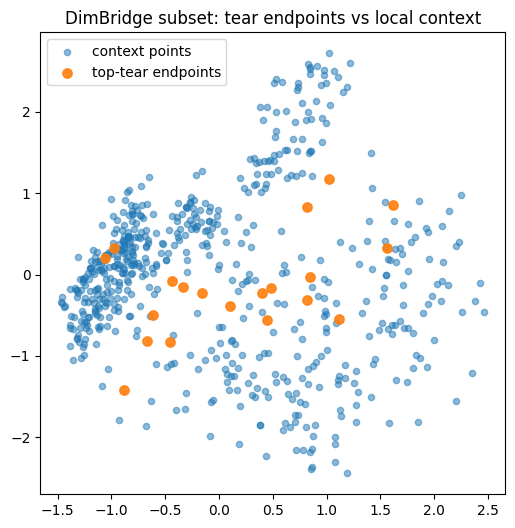

In [21]:
import matplotlib.pyplot as plt
import numpy as np

seed_set = set(seed_idx)
is_seed = np.array([idx in seed_set for idx in idx_dimbridge])

plt.figure(figsize=(6, 6))
plt.scatter(Y_local[~is_seed, 0], Y_local[~is_seed, 1], s=20, alpha=0.5, label="context points")
plt.scatter(Y_local[is_seed, 0], Y_local[is_seed, 1], s=45, alpha=0.9, label="top-tear endpoints")
plt.title("DimBridge subset: tear endpoints vs local context")
plt.legend()
plt.show()